In [1]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 35.8 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 39.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [cartopy]m3/4 [cartopy]


/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/venv/lib/python3.11/site-packages/cartopy/io/__init__.p

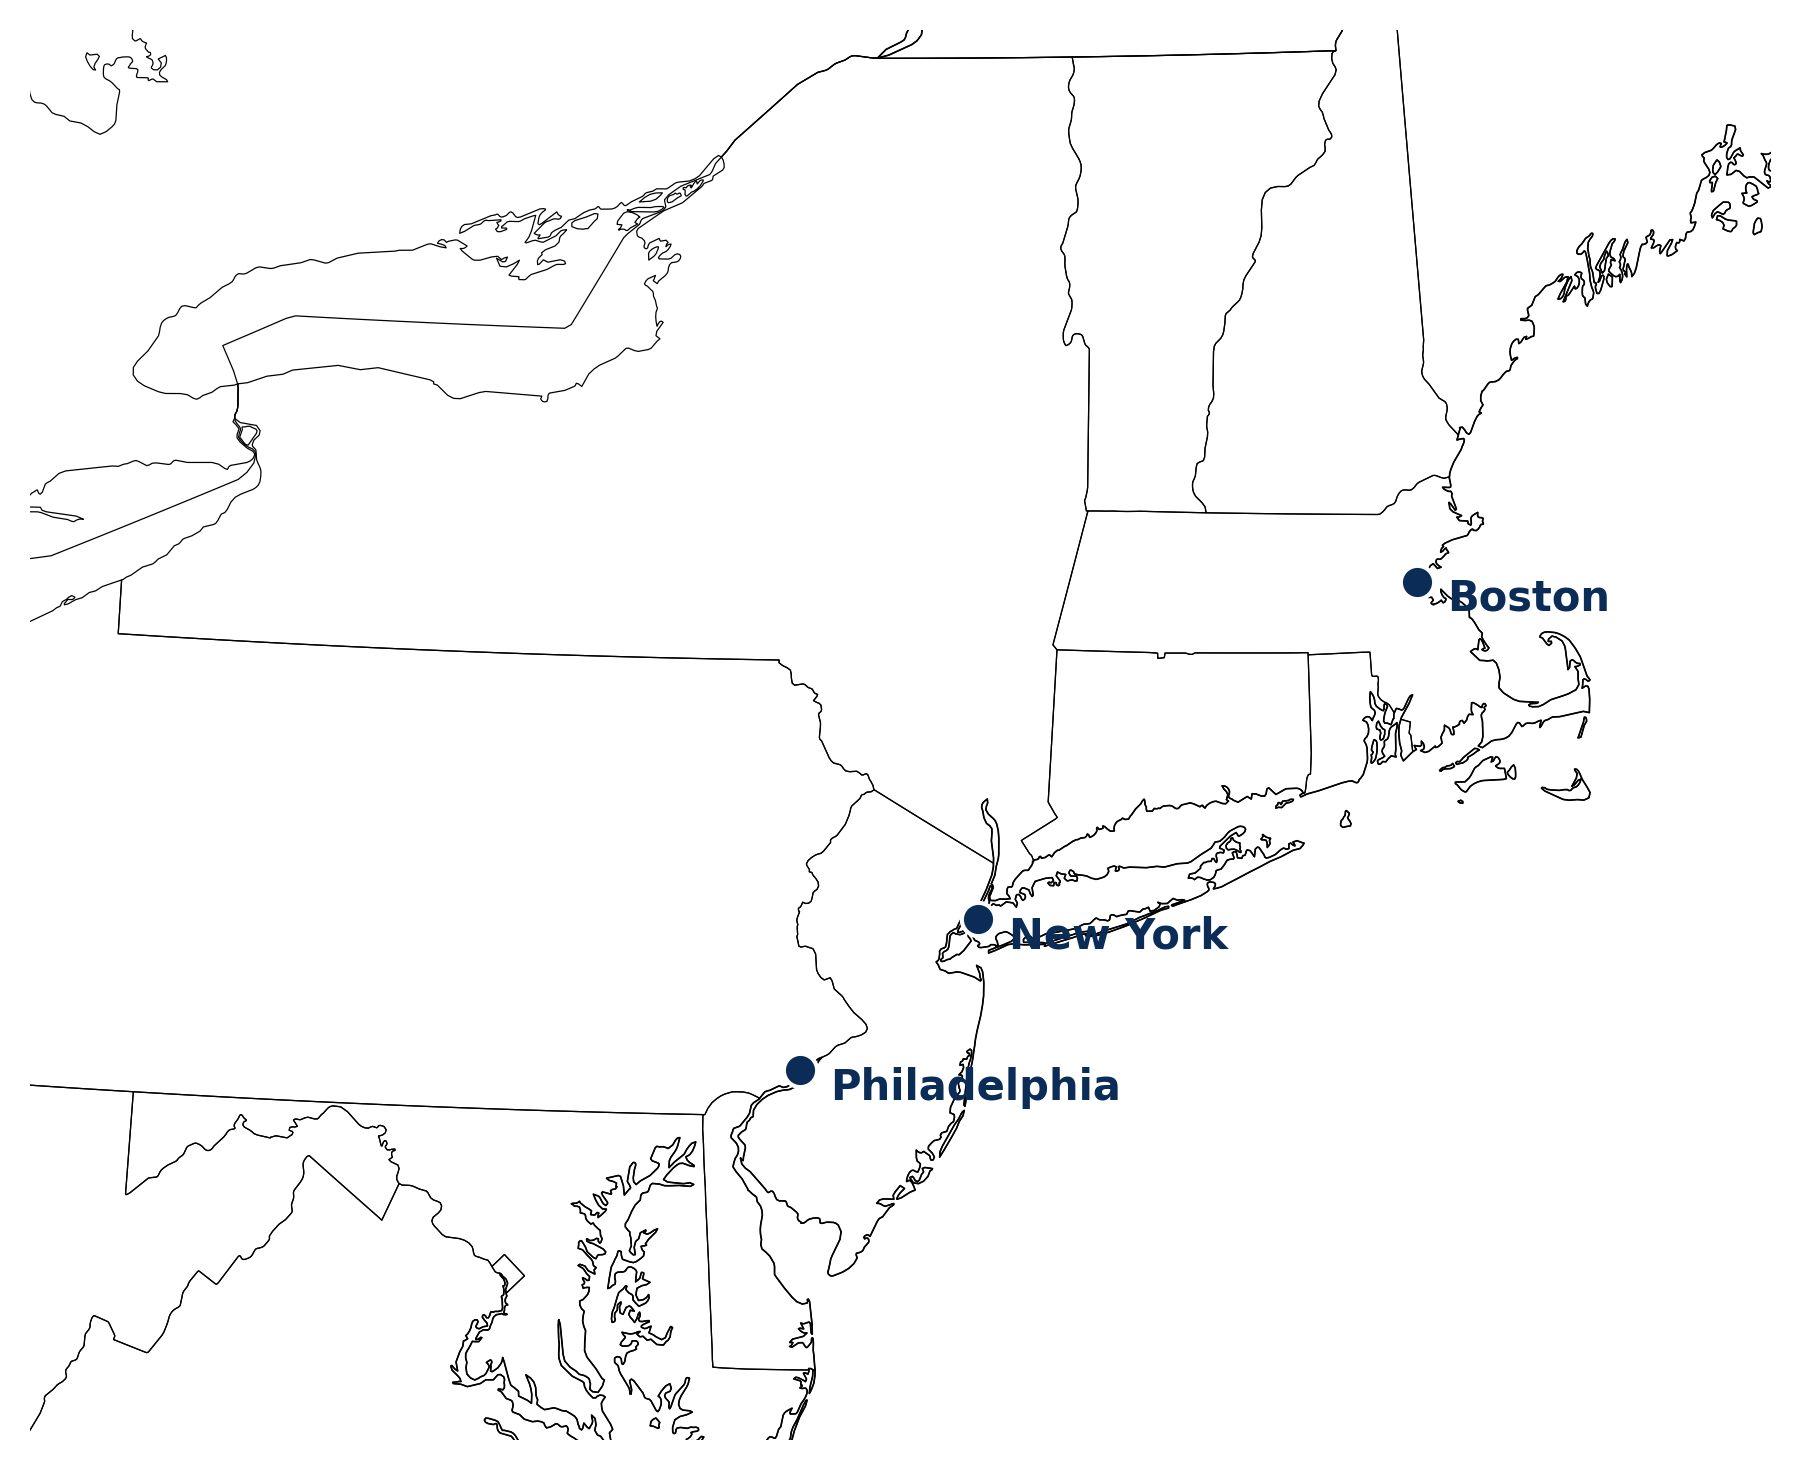

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Coordenadas (latitud, longitud)
cities = {
    "New York":     (40.7128, -74.0060),
    "Philadelphia": (39.9526, -75.1652),
    "Boston":       (42.3601, -71.0589),
}

# Proyección y figura
fig = plt.figure(figsize=(10, 5), dpi=300)
proj = ccrs.LambertConformal(central_longitude=-74, central_latitude=41)
ax = plt.axes(projection=proj)

# Zona “zoomed in” del noreste de EEUU
ax.set_extent([-80, -69, 38, 45], crs=ccrs.PlateCarree())

# Estilo de mapa (puedes ajustar grosores o quitar lo que no quieras)
ax.add_feature(cfeature.LAND, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.STATES, linewidth=0.3)

# Dibujar las ciudades
for name, (lat, lon) in cities.items():
    # marcador tipo "pin" sencillo (círculo)
    ax.plot(
        lon, lat,
        marker="o",
        markersize=8,
        markeredgecolor="white",
        markerfacecolor="#0b2c57",   # azul DS Market, cámbialo si quieres
        transform=ccrs.PlateCarree(),
        zorder=5,
    )
    # etiqueta de texto
    ax.text(
        lon + 0.2, lat - 0.15, name,
        transform=ccrs.PlateCarree(),
        fontsize=10,
        color="#0b2c57",
        weight="bold",
        zorder=6,
    )

# Quitar ejes / bordes de gráfico
ax.axis("off")

plt.tight_layout()

# Guardar con fondo transparente para usar en la slide
plt.savefig("mapa_dsmarket_transparente.png",
            transparent=True, bbox_inches="tight", pad_inches=0)

plt.show()
